### Lab 7
#### 7.8.1 Polynomial Regression and Step Functions

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

In [5]:
wage = pd.read_csv("data/Wage.csv")

model_raw = smf.ols(formula="wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=wage).fit()
print("--- Row polinomial ---")
print(model_raw.summary())

--- Row polinomial ---
                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.086
Model:                            OLS   Adj. R-squared:                  0.085
Method:                 Least Squares   F-statistic:                     70.69
Date:                Wed, 24 Jun 2026   Prob (F-statistic):           2.77e-57
Time:                        13:41:36   Log-Likelihood:                -15315.
No. Observations:                3000   AIC:                         3.064e+04
Df Residuals:                    2995   BIC:                         3.067e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercept    -184.1542     

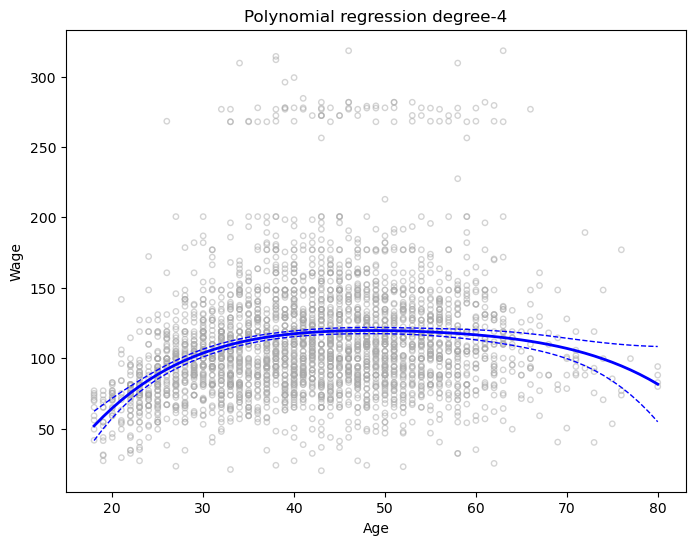

In [8]:
age_grid = pd.DataFrame({"age": np.arange(wage.age.min(), wage.age.max() + 1)})

predictions = model_raw.get_prediction(age_grid)
pred_summary = predictions.summary_frame(alpha=0.05)

plt.figure(figsize=(8, 6))
plt.scatter(wage.age, wage.wage, facecolors="none", edgecolors="darkgrey", s=15, alpha=0.5)
plt.plot(age_grid.age, pred_summary["mean"], color="blue", lw=2, label="Degree-4 Polynomial")
plt.plot(age_grid.age, pred_summary["mean_ci_lower"], color="blue", linestyle="--", lw=1)
plt.plot(age_grid.age, pred_summary["mean_ci_upper"], color="blue", linestyle="--", lw=1)
plt.xlabel("Age")
plt.ylabel("Wage")
plt.title("Polynomial regression degree-4")
plt.show()

Based on the chart and calculated table above, we can draw next conclusions:
- The model captured the underlying trend and generated a smooth curve through the data point cloud
- the train accuracy is quite low $R^2=0.086$, only 8% of wage variance was explained
- Three features (age, $age^2$, and $age^3$) turned out to be statistically significant
- The 4th-degree polynomial term is strictly non-significant at the 5% level ($p = 0.051$)
- The confidence intervals widen at both tails of the curve due to less data density at the age extremes

In [12]:
wage["age_bins"] = pd.cut(wage.age, bins=4)

print("\n--- Bins distribution ---")
print(wage["age_bins"].value_counts().sort_index())

model_bins = smf.ols(formula="wage ~ age_bins", data=wage).fit()
print("\n--- The step function result ---")
print(model_bins.summary().tables[1])


--- Bins distribution ---
age_bins
(17.938, 33.5]     750
(33.5, 49.0]      1399
(49.0, 64.5]       779
(64.5, 80.0]        72
Name: count, dtype: int64

--- The step function result ---
                                                       coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------------
Intercept                                           94.1584      1.476     63.790      0.000      91.264      97.053
age_bins[T.Interval(33.5, 49.0, closed='right')]    24.0535      1.829     13.148      0.000      20.466      27.641
age_bins[T.Interval(49.0, 64.5, closed='right')]    23.6646      2.068     11.443      0.000      19.610      27.719
age_bins[T.Interval(64.5, 80.0, closed='right')]     7.6406      4.987      1.532      0.126      -2.139      17.420


After performing step function on the full data set we can clearly see that, the feature Age was divided on 4 groups (dummy variable). The youngest age group was automatically selected as the reference (baseline) category

The baseline mean wage for the youngest group (ages 17.9 to 33.5) is 94.16. As age increases, the first significant shift occurs in the second group (ages 33.5 to 49.0), increasing the mean wage by 24.05 to a total of 118.21, and so on

The oldest age group (ages 64.5 to 80.0) shows the smallest mean increase (7.64), which is statistically indistinguishable from the baseline group ($p = 0.126$)

In [15]:
from statsmodels.stats.anova import anova_lm

fit_1 = smf.ols(formula="wage ~ age", data=wage).fit()
fit_2 = smf.ols(formula="wage ~ age + I(age**2)", data=wage).fit()
fit_3 = smf.ols(formula="wage ~ age + I(age**2) + I(age**3)", data=wage).fit()
fit_4 = smf.ols(formula="wage ~ age + I(age**2) + I(age**3) + I(age**4)", data=wage).fit()
fit_5 = smf.ols(formula="wage ~ age + I(age**2) + I(age**3) + I(age**4) + I(age**5)", data=wage).fit()

anova_results = anova_lm(fit_1, fit_2, fit_3, fit_4, fit_5)
print(anova_results)

   df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0    2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1    2997.0  4.793430e+06      1.0  228786.010128  143.593107  2.363850e-32
2    2996.0  4.777674e+06      1.0   15755.693664    9.888756  1.679202e-03
3    2995.0  4.771604e+06      1.0    6070.152124    3.809813  5.104620e-02
4    2994.0  4.770322e+06      1.0    1282.563017    0.804976  3.696820e-01


The ANOVA analysis showed:

The 4th-degree polynomial model is on the verge of statistical significance ($p \approx 0.051$).

While the 2nd-degree polynomial provides the largest marginal improvement in fit ($F = 143.59$), the sequential ANOVA test suggests that the cubic (3rd-degree) term is still highly statistically significant ($p = 0.0017$). Therefore, a 3rd or 4th-degree polynomial should be preferred to avoid underfitting